In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn import metrics
plt.style.use('seaborn-v0_8-bright')
plt.rcParams["font.family"] = "monospace"
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True

import import_helper
import_helper.add_functions()
import neuruloid_segmentation.process_intensities as process
import neuruloid_segmentation.fitting_intensities as fit
import neuruloid_segmentation.utils as u

### Fitting TBXT data with simple exponential model

For a simple diffusion-degradation model, we fit the equation
\begin{align}
c_s(x) = \frac{1}{1+e^{-2L/\lambda}} (e^{-x/\lambda} + e^{-2L/\lambda}e^{x/\lambda})
\end{align}

where $L$ is the radius of micropattern, assuming radial symmetry in TBXT patterning. We obtain the decay length scale $\lambda$, then simulate in 2D (show no steady state if there is constant increased sensitivity to activator at the neuruloid edge??).

Setting the $L=1$ for a normalised domain length, we find the relation $\gamma \propto R$ where $\gamma = 1/\lambda$.

In [22]:
# obtain TBXT data
TBXT_intensity_data_folder = "../intensity_data"
ctrl_circle_data = "single_z_slices_24hr/circle_ctrl"
data_folder_path = os.path.join(TBXT_intensity_data_folder, ctrl_circle_data)

data_names_sizes = {"ctrl_250":250, "ctrl_350":350, 
                    "ctrl_400":400, "ctrl_500":500}
data_color = {"ctrl_250":"red", "ctrl_350":"blue", 
              "ctrl_400":"green", "ctrl_500":"purple"}

In [17]:
# function to fit
def c_s(x, lam):
    return (np.exp(-x/lam) + np.exp(-2/lam) * np.exp(x/lam)) / (1 + np.exp(-2/lam))

In [18]:
def fitting(xdata, ydata):
    initial_guess = [0.1]
    popt, pcov = curve_fit(c_s, xdata, ydata, p0=initial_guess)
    fitted_lambda = popt[0]
    lambda_err = np.sqrt(np.diag(pcov))[0]
    return fitted_lambda, lambda_err

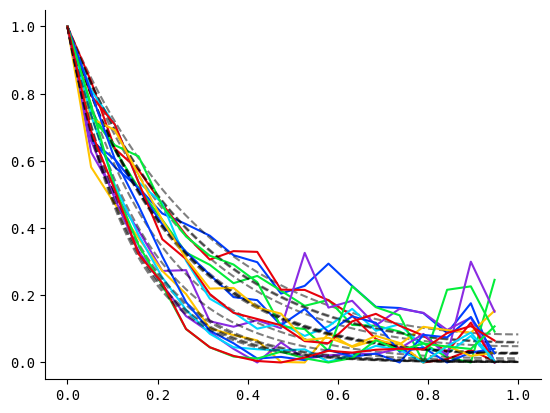

In [34]:
# make a dictionary of all the lambda values for different radii
fitted_lambda_array = []
radius_sizes_array = []

for data_name in list(data_names_sizes.keys()):

    sample_names = os.listdir((os.path.join(data_folder_path, data_name)))

    for i in range(len(sample_names)):

        # get df of the sample
        df = pd.read_csv(os.path.join(f"{data_folder_path}/{data_name}", sample_names[i]))
        discrete_dict = np.linspace(0, np.max(df["distance"].to_numpy()), 20)
        normalise_max_df = process.process_raw_to_norm_dataframe(df,
                                                                 discrete_dict,
                                                                 channels=[3],
                                                                 subtract_bg=[True])
        
        tbxt_dist = discrete_dict / np.max(discrete_dict)
        tbxt_intensity = normalise_max_df["channel_3"].to_numpy()

        fitted_lambda, _ = fitting(tbxt_dist[:-1], tbxt_intensity)

        plt.plot(tbxt_dist[:-1], tbxt_intensity, label=sample_names[i])
        x = np.linspace(0, 1, 100)
        plt.plot(x, c_s(x, fitted_lambda), linestyle='--', color='black', alpha=0.5)

        fitted_lambda_array.append(fitted_lambda)
        radius_sizes_array.append(data_names_sizes[data_name] / 2)
 

In [37]:
print(np.array(fitted_lambda_array))

[0.31516505 0.26884761 0.28436576 0.19697174 0.14883166 0.23670437
 0.23374536 0.28687343 0.2300992  0.13914805 0.23313724 0.15222375
 0.17263722 0.14165716 0.13550552]


In [38]:
radius = np.array(radius_sizes_array)
gamma = 1 / np.array(fitted_lambda_array)
slope, r_squared = u.fit_proportional_line_and_evaluate(radius, gamma)
print(radius)

[125. 125. 125. 175. 175. 175. 175. 175. 200. 200. 200. 250. 250. 250.
 250.]


(2.0, 7.74876188255534)

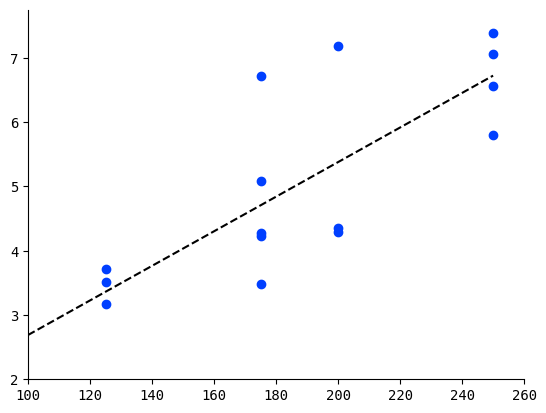

In [43]:
# plot linear line
fig, ax = plt.subplots()
ax.scatter(radius, gamma)
x = np.linspace(0, 250, 10)
y = slope * x 
ax.plot(x, y, color="black", linestyle="--")
ax.set_xlim(100, 260)
ax.set_ylim(2,)